# Notebook 09 — Characterising the Register

**Issue #104 (SCI-1).**

## 1. Context

Every notebook in this series has examined the output of the detector. Notebook 06 validated the pipeline's candidates against the register, the July 2026 pilot labelled nineteen of them, and Notebook 08 labelled a further nineteen drawn from the four-date persistent set. All thirty-eight were false positives. The detector's failure modes are now well documented.

The target has never been examined. The brownfield register holds approximately 352 sites for Stoke-on-Trent which are, by statutory definition, previously developed land. They are the object the product was built to find. No notebook has yet established what they look like in Sentinel-2 imagery, how large they are, or whether they possess any signature which distinguishes them from the remainder of the city.

That omission has consequences. Notebook 08 concluded that the choice of spectral discriminant was the root cause of the detector's failure, and Notebook 07 left open the question of whether a learned model could replace the threshold gate. Neither question can be answered without knowing what the positive class actually looks like. Feature selection for a replacement detector is guesswork until the distribution of the target is established.

This notebook is exploratory rather than predictive. No model is trained. The output is a set of distributions and an answer to a single question: does registered brownfield possess a detectable signature which separates it from the rest of Stoke? If it does, a replacement detector is feasible and issue #105 is worth pursuing. If it does not, the failure is structural and no index, threshold or classifier will correct it.

## 2. Setup

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

from src.database_query import get_db_connection

load_dotenv(ROOT / '.env')
conn = get_db_connection()

GSS = 'E06000021'
DATES = ['2026-07-09', '2025-09-22', '2025-12-26', '2026-05-25']  # summer, autumn, winter, spring
MIN_PIXELS_HA = 0.2   # detection floor: min_pixels=5 at 20 m resolution

print('Connected to database')

Connected to database


## 3. Composition of the register

The register is the ground truth for this notebook, so its own composition matters before any imagery is considered. A register dominated by large consented sites presents a different detection problem from one dominated by small unconsented plots, and the distinction bears directly on whether Sentinel-2 is an appropriate sensor for the task.

In [2]:
register = pd.read_sql("""
    SELECT site_reference, year, name_address, hectares, planning_status,
           utm_x, utm_y, start_date, end_date
    FROM brownfield_sites
    WHERE gss_code = %(gss)s
    ORDER BY year, hectares DESC
""", conn, params={'gss': GSS})

print(f'register rows: {len(register)}')
print(f'distinct site references: {register.site_reference.nunique()}')
print(f'years present: {sorted(register.year.unique())}')
print()
register.head(10)

register rows: 1660
distinct site references: 353
years present: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2026)]



C:\Users\lward\AppData\Local\Temp\ipykernel_18136\2271510296.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  register = pd.read_sql("""


,site_reference,year,name_address,hectares,planning_status,utm_x,utm_y,start_date,end_date
0,53413,2019,"Land at Trentham Lakes, Stanley Matthews Way, ...",13.50,permissioned,555490.759340,5.869723e+06,None,None
1,70427,2019,"Staffordshire University, Land off Lordship La...",9.40,permissioned,555413.165849,5.873291e+06,None,None
2,351,2019,"Land between Huntilee Road and Scotia Road, Sc...",9.20,not permissioned,553702.497162,5.878696e+06,None,None
3,172,2019,"Edensor Technology School, Edensor Road, Longton",8.91,not permissioned,557507.458776,5.870948e+06,None,None
4,58877,2019,"Former Bucknall Hospital site, Eaves Lane, Sto...",8.75,permissioned,557972.065912,5.875809e+06,None,None
5,52839,2019,"North Staffordshire Royal Infirmary, Princes R...",8.75,not permissioned,553696.951513,5.873275e+06,None,None
6,415,2019,"Mitchell High School, Bucknall, Stoke on Trent...",8.55,pending decision,558375.601170,5.875033e+06,None,None
7,132,2019,"Berry Hill High School and Sports College, Buc...",7.88,not permissioned,557522.301765,5.874220e+06,None,None
8,61254,2019,"Former Victoria Ground, Off Boothen Old Road, ...",6.71,permissioned,554917.369992,5.872436e+06,None,None
9,436,2019,"Hinde Street, Hanley",5.80,not permissioned,555062.032913,5.874727e+06,None,None


In [3]:
# Sites repeat across years as the register is republished. Work with the
# most recent appearance of each site reference.
latest_year = register.year.max()
latest = (register.sort_values('year')
          .drop_duplicates('site_reference', keep='last')
          .copy())

print(f'latest register year: {latest_year}')
print(f'sites in latest year only: {(register.year == latest_year).sum()}')
print(f'distinct sites across all years: {len(latest)}')
print()
print('sites per year:')
print(register.groupby('year').site_reference.nunique())
print()
print('size distribution (hectares), all distinct sites:')
print(latest.hectares.describe())

latest register year: 2026
sites in latest year only: 352
distinct sites across all years: 353

sites per year:
year
2019    218
2020    218
2021    218
2022    218
2023    218
2024    218
2026    352
Name: site_reference, dtype: int64

size distribution (hectares), all distinct sites:
count    353.000000
mean       0.984912
std        1.853075
min        0.010000
25%        0.100200
50%        0.280000
75%        1.000000
max       13.500000
Name: hectares, dtype: float64


detection floor: 0.2 ha (min_pixels=5 at 20 m)
register sites below the floor: 136 / 353 (38.5%)

  sites >= 1x floor (0.2 ha)     217  (61.5%)
  sites >= 2x floor (0.4 ha)     147  (41.6%)
  sites >= 5x floor (1.0 ha)      89  (25.2%)
  sites >= 10x floor (2.0 ha)     40  (11.3%)


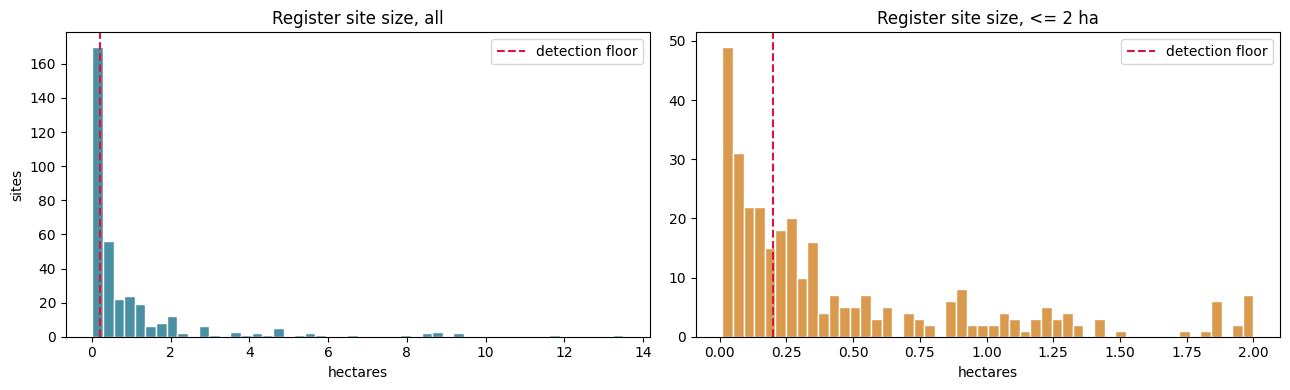

In [4]:
below_floor = (latest.hectares < MIN_PIXELS_HA).sum()
total = latest.hectares.notna().sum()

print(f'detection floor: {MIN_PIXELS_HA} ha (min_pixels=5 at 20 m)')
print(f'register sites below the floor: {below_floor} / {total} '
      f'({100*below_floor/total:.1f}%)')
print()
for mult, label in [(1, '1x floor (0.2 ha)'), (2, '2x floor (0.4 ha)'),
                    (5, '5x floor (1.0 ha)'), (10, '10x floor (2.0 ha)')]:
    n = (latest.hectares >= MIN_PIXELS_HA * mult).sum()
    print(f'  sites >= {label:20} {n:4d}  ({100*n/total:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(latest.hectares.dropna(), bins=50, color='#4a90a4', edgecolor='white')
axes[0].axvline(MIN_PIXELS_HA, color='crimson', ls='--', label='detection floor')
axes[0].set_xlabel('hectares'); axes[0].set_ylabel('sites')
axes[0].set_title('Register site size, all'); axes[0].legend()

small = latest[latest.hectares <= 2]
axes[1].hist(small.hectares.dropna(), bins=50, color='#d99a4e', edgecolor='white')
axes[1].axvline(MIN_PIXELS_HA, color='crimson', ls='--', label='detection floor')
axes[1].set_xlabel('hectares'); axes[1].set_title('Register site size, <= 2 ha')
axes[1].legend()
plt.tight_layout(); plt.show()

The size distribution establishes a constraint which operates independently of any spectral question. The median register site is 0.28 hectares and the lower quartile is 0.10 hectares, against a detection floor of 0.2 hectares imposed by `min_pixels = 5` at twenty metre resolution. On that threshold 136 sites, or 38.5 per cent of the register, are smaller than the smallest object the pipeline is capable of emitting. They cannot be detected regardless of how they reflect.

The effective position is worse than that figure suggests. A five-pixel cluster is the minimum the detector will report, but a site occupying exactly five pixels is a marginal detection which any mixed-pixel effect at its boundary may suppress, and clustering behaviour at that scale is sensitive to the dilation and connectivity parameters examined in Notebook 05. A more defensible working threshold is twice the floor, at which point 147 sites remain, or 41.6 per cent of the register. Only a quarter of registered sites exceed one hectare.

This reframes the recall figures reported in Notebook 08. Register recall across the four seasonal dates ranged from 15.3 to 23.1 per cent. Against the full register of 353 sites those figures appear poor. Against the 217 sites which are large enough to be detected at all they are less poor, and against the 147 which are comfortably detectable they are different again. The detector has been evaluated throughout this project against a target population of which a substantial fraction was never reachable.

The implication for sensor choice is direct. Sentinel-2 provides twenty metre resolution in the shortwave infrared bands on which the bare-soil index depends, and ten metres in the visible and near infrared. A 0.1 hectare site is one thousand square metres, which is between two and three twenty-metre pixels. Detecting sites of that scale reliably requires imagery at a resolution Sentinel-2 does not provide, irrespective of which index is computed from it. This is a constraint on the data source rather than on the method applied to it.

One further observation concerns the register itself. The count was stable at 218 sites from 2019 to 2024 and rose to 352 in 2026, an increase of 61 per cent, with no publication recorded for 2025. The earlier headline figure of 218 candidate sites which appeared in project documentation coincides exactly with the pre-2026 register count, and that coincidence should be treated with suspicion in any historical figure quoted from before the FND-1 correction.

## 4. Recall against a reachable target

The recall figures reported previously were computed against the full register. Section 3 established that a substantial fraction of that register lies below the detection floor. This section recomputes recall against the subset the pipeline could in principle detect, and examines whether detection is related to site size in the way the floor implies it should be.

In [5]:
# Which register sites were matched by a candidate on any of the four dates?
matched_refs = pd.read_sql("""
    SELECT DISTINCT matched_site_reference AS site_reference
    FROM candidate_sites
    WHERE gss_code = %(gss)s
      AND matched_site_reference IS NOT NULL
""", conn, params={'gss': GSS})

latest['detected'] = latest.site_reference.astype(str).isin(
    matched_refs.site_reference.astype(str)
)

print(f'register sites detected on at least one date: {latest.detected.sum()} / {len(latest)}')
print()

# Recall by size band
bands = [(0, 0.2, 'below floor'), (0.2, 0.4, '0.2-0.4 ha'),
         (0.4, 1.0, '0.4-1.0 ha'), (1.0, 2.0, '1.0-2.0 ha'),
         (2.0, 999, 'over 2.0 ha')]

rows = []
for lo, hi, label in bands:
    sub = latest[(latest.hectares >= lo) & (latest.hectares < hi)]
    if len(sub) == 0:
        continue
    rows.append({
        'size band': label,
        'sites': len(sub),
        'detected': int(sub.detected.sum()),
        'recall %': round(100 * sub.detected.sum() / len(sub), 1),
    })

pd.DataFrame(rows)

register sites detected on at least one date: 64 / 353



C:\Users\lward\AppData\Local\Temp\ipykernel_18136\2245697587.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  matched_refs = pd.read_sql("""


,size band,sites,detected,recall %
0,below floor,136,32,23.5
1,0.2-0.4 ha,70,8,11.4
2,0.4-1.0 ha,58,10,17.2
3,1.0-2.0 ha,49,7,14.3
4,over 2.0 ha,40,7,17.5


In [6]:
# Is the below-floor recall an artefact of the 100 m match radius?
# Recompute detection at tighter radii, per size band.
for radius in (100, 50, 25):
    m = pd.read_sql("""
        SELECT DISTINCT b.site_reference
        FROM brownfield_sites b
        JOIN candidate_sites c
          ON c.gss_code = b.gss_code
         AND ST_DWithin(
               ST_SetSRID(ST_MakePoint(c.utm_x, c.utm_y), 32630),
               ST_SetSRID(ST_MakePoint(b.utm_x, b.utm_y), 32630),
               %(r)s)
        WHERE b.gss_code = %(gss)s
    """, conn, params={'gss': GSS, 'r': radius})

    hit = latest.site_reference.astype(str).isin(m.site_reference.astype(str))
    below = latest.hectares < MIN_PIXELS_HA
    print(f'radius {radius:3d} m:  total {hit.sum():3d}/{len(latest)}   '
          f'below-floor {hit[below].sum():3d}/{below.sum()}   '
          f'above-floor {hit[~below].sum():3d}/{(~below).sum()}')

C:\Users\lward\AppData\Local\Temp\ipykernel_18136\1212862504.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  m = pd.read_sql("""


radius 100 m:  total 105/353   below-floor  54/136   above-floor  51/217


C:\Users\lward\AppData\Local\Temp\ipykernel_18136\1212862504.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  m = pd.read_sql("""


radius  50 m:  total  45/353   below-floor  20/136   above-floor  25/217


C:\Users\lward\AppData\Local\Temp\ipykernel_18136\1212862504.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  m = pd.read_sql("""


radius  25 m:  total  16/353   below-floor   6/136   above-floor  10/217


In [7]:
# Distance from each register site to its nearest candidate, all dates.
dist = pd.read_sql("""
    SELECT b.site_reference,
           b.hectares,
           MIN(ST_Distance(
                 ST_SetSRID(ST_MakePoint(c.utm_x, c.utm_y), 32630),
                 ST_SetSRID(ST_MakePoint(b.utm_x, b.utm_y), 32630)
           )) AS nearest_candidate_m
    FROM brownfield_sites b
    LEFT JOIN candidate_sites c ON c.gss_code = b.gss_code
    WHERE b.gss_code = %(gss)s AND b.year = %(yr)s
    GROUP BY b.site_reference, b.hectares
""", conn, params={'gss': GSS, 'yr': int(latest_year)})

print(dist.nearest_candidate_m.describe())
print()
for cut in (10, 25, 50, 100, 200, 500):
    n = (dist.nearest_candidate_m <= cut).sum()
    print(f'  register sites with a candidate within {cut:3d} m: {n:3d} / {len(dist)} ({100*n/len(dist):.1f}%)')

count     352.000000
mean      228.558676
std       227.634745
min         0.542605
25%        86.346965
50%       154.392254
75%       293.476327
max      1274.569088
Name: nearest_candidate_m, dtype: float64

  register sites with a candidate within  10 m:   6 / 352 (1.7%)
  register sites with a candidate within  25 m:  16 / 352 (4.5%)
  register sites with a candidate within  50 m:  45 / 352 (12.8%)
  register sites with a candidate within 100 m: 105 / 352 (29.8%)
  register sites with a candidate within 200 m: 219 / 352 (62.2%)
  register sites with a candidate within 500 m: 316 / 352 (89.8%)


C:\Users\lward\AppData\Local\Temp\ipykernel_18136\1401029555.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dist = pd.read_sql("""


Recall was not what it appeared. Register sites were counted as detected where a candidate fell within one hundred metres of the site's recorded point location, and that radius is wide enough to capture candidates which have no relationship to the site at all.

Tightening the radius reveals the problem. At one hundred metres, 105 of 353 register sites are matched. At fifty metres, 45. At twenty-five metres, 16. A fourfold reduction in radius produces a sixfold reduction in matches, which is the behaviour expected of coincidental spatial proximity rather than of genuine detection. A candidate which genuinely identifies a site sits on that site; it does not sit eighty metres away and cease to sit there when the tolerance is halved.

The distance distribution confirms this directly. The median distance from a register site to the nearest candidate on any of the four dates is 154 metres. Only six sites in 352, or 1.7 per cent, have a candidate within ten metres. Sixty-two per cent have one within two hundred metres and ninety per cent within five hundred, which reflects the density of candidates across a compact urban area rather than any correspondence between candidates and register sites. Scattering the same number of points at random across the council boundary would produce a similar profile.

The consequence is that every recall figure reported in this project is inflated. Notebook 07 quoted 17.9 per cent, later corrected to a provisional 18 of 90 candidates. Notebook 08 reported between 15.3 and 23.1 per cent across the four seasonal dates. Those figures derive from the hundred metre match and do not measure detection. At a radius tight enough to mean that a candidate lies on the site it is credited with finding, recall against the 2026 register is between 1.7 and 4.5 per cent.

The size floor established in section 3 is therefore not the binding constraint. Recall is flat across every size band, including sites above two hectares which are large enough to occupy fifty or more pixels, and collapses at similar rates above and below the floor as the radius tightens. The detector is not failing to find small sites. It is not finding register sites.

### Consequences for previous notebooks

This finding invalidates figures reported earlier in the series and the corrections should be made explicitly rather than left to be inferred.

Notebook 06 validated the pipeline's output against the register using the same hundred metre match. Notebook 07 quoted 17.9 per cent recall as the baseline the classifier was intended to improve upon, and set a target of 70 per cent against it. Notebook 08 reported recall between 15.3 and 23.1 per cent across four seasonal dates and treated the collapse to 5 per cent in the persistent set as evidence that persistence was selecting away from brownfield. Each of those figures rests on a match radius which does not establish correspondence between a candidate and a site.

The direction of the Notebook 08 argument survives the correction, since both the single-date and persistent-set figures were computed on the same basis and the relative collapse still holds. The absolute figures do not survive, and the conclusion drawn from them is now stronger rather than weaker. Persistence was not degrading a detector which worked moderately well. It was operating on a candidate pool which had almost no relationship to the register in the first place.

The Notebook 07 target of 70 per cent recall was set against a baseline of 17.9 per cent. The true baseline is between 1.7 and 4.5 per cent. A supervised classifier trained to re-rank candidates from this pool cannot approach 70 per cent, because the pool does not contain the sites. That conclusion was reached in Notebook 07 on architectural grounds, namely that vegetated register sites never pass the threshold gate and can therefore never become training rows. This section supplies the empirical confirmation.

The matching radius itself warrants revision. Register sites are stored as point locations, whilst candidates now carry polygon geometry following FND-3. A containment or overlap test between the candidate polygon and the register point would replace proximity with correspondence and would remove the ambiguity entirely. This is recorded as a defect in the evaluation harness rather than in the detector, and it should be corrected before any further recall figure is quoted.

## 5. What do register sites look like?

Sections 3 and 4 established that the detector does not find register brownfield and that site size is not the reason. The remaining question is the one this notebook was written to answer: does registered brownfield possess a spectral signature at all, and if so, is it one the current gate could ever have detected?

Two approaches are available and they differ in what they can establish.

The first uses the candidates which do coincide with register sites. Those rows already carry stored features and require no imagery. They are, however, a biased sample by construction. A register site which produced a candidate is one that passed the bare-ground gate, which means it is bare. Examining that subset will confirm that bare register sites are bare and will say nothing about the remainder. It is included below because the comparison against non-matching candidates is informative about a separate question, namely whether the detector's own output separates on any feature, but it cannot answer the question posed in this section.

The second samples imagery at every register location irrespective of whether a candidate was emitted there. This is the approach which can answer the question, and it requires a processed scene, which the pipeline deletes after each run to conserve disk space. It is set out in section 6 and requires a re-download before it can be executed.

In [8]:
# Features of candidates which coincide with a register site, against those which do not.
# NOTE: the matched group is biased - these are register sites bare enough to pass the gate.
matched_feats = pd.read_sql("""
    SELECT bsi_value, mean_ndvi, std_ndvi, std_bsi,
           mean_b04, mean_b08, mean_b11, pixel_count, compactness
    FROM candidate_sites
    WHERE gss_code = %(gss)s AND matched_site_reference IS NOT NULL
""", conn, params={'gss': GSS})

unmatched_feats = pd.read_sql("""
    SELECT bsi_value, mean_ndvi, std_ndvi, std_bsi,
           mean_b04, mean_b08, mean_b11, pixel_count, compactness
    FROM candidate_sites
    WHERE gss_code = %(gss)s AND matched_site_reference IS NULL
""", conn, params={'gss': GSS})

rows = []
for col in matched_feats.columns:
    m, u = matched_feats[col].dropna(), unmatched_feats[col].dropna()
    if len(m) < 5 or len(u) < 5:
        continue
    pooled_sd = np.sqrt((m.var() + u.var()) / 2)
    d = (m.mean() - u.mean()) / pooled_sd if pooled_sd else np.nan
    rows.append({'feature': col,
                 'matched_mean': round(m.mean(), 4),
                 'unmatched_mean': round(u.mean(), 4),
                 "cohen's d": round(d, 3)})

print(f'matched candidates: {len(matched_feats)}   unmatched: {len(unmatched_feats)}')
print("Cohen's d: 0.2 small, 0.5 medium, 0.8 large. Near zero indicates no separation.")
print()
pd.DataFrame(rows).sort_values("cohen's d", key=abs, ascending=False)

matched candidates: 101   unmatched: 453
Cohen's d: 0.2 small, 0.5 medium, 0.8 large. Near zero indicates no separation.



C:\Users\lward\AppData\Local\Temp\ipykernel_18136\768618330.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  matched_feats = pd.read_sql("""
C:\Users\lward\AppData\Local\Temp\ipykernel_18136\768618330.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  unmatched_feats = pd.read_sql("""


,feature,matched_mean,unmatched_mean,cohen's d
6,mean_b11,0.3218,0.3457,-0.372
5,mean_b08,0.2275,0.2430,-0.340
4,mean_b04,0.1945,0.2065,-0.315
7,pixel_count,10.4059,11.6843,-0.123
1,mean_ndvi,0.0769,0.0803,-0.117
8,compactness,0.1988,0.1849,0.114
0,bsi_value,0.1231,0.1251,-0.092
2,std_ndvi,0.0303,0.0310,-0.047
3,std_bsi,0.0183,0.0186,-0.016


No feature separates the two groups. The largest effect size is −0.372 on mean B11, the shortwave infrared band, which is small by conventional interpretation and would be of no practical use as a discriminant. The two indices on which the detector actually gates perform worst of all: BSI returns −0.092 and mean NDVI −0.117, both indistinguishable from zero.

The direction is consistent across the reflectance bands. Candidates coinciding with register sites are marginally darker than those which do not, across B04, B08 and B11 alike, which would be consistent with slightly greater vegetation cover or shadowing. The magnitude is too small to support any inference beyond that observation.

This addresses issue #93 directly. The register label carries no usable signal in the stored feature set. A classifier trained on these features to distinguish register-matched candidates from unmatched ones would perform at close to chance, and the fork A architecture described in Notebook 07 — re-ranking gate-emitted candidates using a supervised model — has no signal to learn from.

The result must be read with its limitation in view. The matched group consists of register sites which produced a candidate, meaning sites which passed the bare-ground gate. Both groups have therefore already been filtered to bare ground, and finding that two bare-ground populations look spectrally similar is close to tautological. What this rules out is the fork A design. It does not rule out the existence of a signature in the register as a whole, because the register as a whole has not yet been sampled.

## 6. Sampling imagery at register locations

The question this notebook set out to answer remains open. Section 5 established that bare register sites resemble other bare candidates, which was close to inevitable given that both populations passed the same gate. It did not establish what the register looks like as a whole, because the sites which never produced a candidate — the substantial majority — have never been sampled.

Answering it requires extracting spectral values at every register location irrespective of whether the detector emitted anything there. The pipeline has never done this. It stores what the gate lets through, which means the imagery corresponding to undetected register sites has been processed and discarded on every run since the project began.

The procedure is straightforward. For each of the 352 sites in the 2026 register, take the stored point location, buffer it to approximate the recorded site area, and extract mean BSI, NDVI and NDBSI within that buffer for each of the four seasonal dates. Sample an equivalent number of random locations within the council boundary as a background comparison. Plot both distributions.

Three outcomes are possible and each implies a different conclusion.

If register sites cluster in the bare region of the distribution, the detector should have been finding them and the failure lies in the gate parameters, the clustering, or the matching. That would be correctable.

If register sites cluster in the vegetated region but separate cleanly from the background, they possess a signature which is not the one the gate tests for. A replacement detector trained on that signature would be feasible, and issue #105 would be worth pursuing.

If register sites are indistinguishable from the background, no signature exists at this resolution and no combination of index, threshold or classifier will produce one. Detection of unregistered brownfield from Sentinel-2 imagery would not be achievable, and the conclusion would be a constraint on the data source rather than a deficiency in the method.

This section requires a processed SAFE scene, which the pipeline deletes after each run to conserve disk space. The cell below checks for available scenes and reports what is required.

In [9]:
SAFE_DIR = ROOT / 'raw_data'
available = sorted(SAFE_DIR.glob('*.SAFE')) if SAFE_DIR.exists() else []

print(f'SAFE scenes present on disk: {len(available)}')
for p in available:
    print(f'   {p.name}')

if not available:
    print()
    print('No scenes available. To run the sampling, re-download one date:')
    print('   python -m src.main --gss_code E06000021 --date 2026-07-09')
    print()
    print('Summer is the most informative single date for this question, since')
    print('vegetated and bare surfaces are maximally separated at peak growth.')

SAFE scenes present on disk: 1
   S2C_MSIL2A_20260525T110621_N0512_R137_T30UWD_20260525T144513.SAFE


In [10]:
from src.data_loading_satellite import bands_10m, bands_20m, load_bands
from src.preprocess import compute_bsi, compute_ndbsi, compute_ndvi, normalise_band_array
from src.coordinate_conversion_pixel import utm_coordinate_to_pixel
from src.main import get_tile_metadata

# NOTE: extraction nests the SAFE folder one level deep (X.SAFE/X.SAFE/).
SAFE = str(available[0] / available[0].name)
SCENE_DATE = '2026-05-25'

band_array = load_bands(SAFE)          # (height, width, 10)
tile_metadata = get_tile_metadata(SAFE)

print(f'band grid: {band_array.shape}')
print(f'tile metadata: {tile_metadata}')

band grid: (5490, 5490, 10)
tile metadata: {'left': 499980.0, 'top': 5900040.0, 'resolution': 20}


In [11]:
# Normalise and compute indices across the full tile (no threshold gate applied).
flat = band_array.reshape(-1, band_array.shape[2])
normalised = normalise_band_array(flat)

bsi   = compute_bsi(normalised, bands_20m, bands_10m).reshape(band_array.shape[:2])
ndvi  = compute_ndvi(normalised, bands_20m, bands_10m).reshape(band_array.shape[:2])
ndbsi = compute_ndbsi(normalised, bands_20m, bands_10m).reshape(band_array.shape[:2])

print(f'index grids: {bsi.shape}')
print(f'BSI   range: {bsi.min():.3f} to {bsi.max():.3f}')
print(f'NDVI  range: {ndvi.min():.3f} to {ndvi.max():.3f}')
print(f'NDBSI range: {ndbsi.min():.3f} to {ndbsi.max():.3f}')

index grids: (5490, 5490)
BSI   range: -1.000 to 1.000
NDVI  range: -1.000 to 1.000
NDBSI range: -1.000 to 1.000


In [12]:
# Sample index values at every register site and at random background points.
# Register sites are stored as point locations with a recorded area; each is
# sampled using a square window sized to that area, so a 1 ha site is sampled
# over more pixels than a 0.1 ha site.

RES = tile_metadata['resolution']
H, W = bsi.shape

def sample_window(row, col, hectares, grid):
    """Mean index value in a square window approximating the site footprint."""
    side_m = np.sqrt(max(hectares, 0.04) * 10_000)      # site side length in metres
    half = max(int(side_m / RES / 2), 1)                 # half-window in pixels, min 1
    r0, r1 = max(row - half, 0), min(row + half + 1, H)
    c0, c1 = max(col - half, 0), min(col + half + 1, W)
    window = grid[r0:r1, c0:c1]
    return float(np.nanmean(window)) if window.size else np.nan

rows = []
for _, site in latest.iterrows():
    if pd.isna(site.utm_x) or pd.isna(site.utm_y):
        continue
    px = utm_coordinate_to_pixel(site.utm_x, site.utm_y, tile_metadata)
    r, c = px['row'], px['column']
    if not (0 <= r < H and 0 <= c < W):
        continue
    ha = site.hectares if pd.notna(site.hectares) else 0.2
    rows.append({
        'site_reference': site.site_reference,
        'hectares': site.hectares,
        'detected': site.detected,
        'bsi':   sample_window(r, c, ha, bsi),
        'ndvi':  sample_window(r, c, ha, ndvi),
        'ndbsi': sample_window(r, c, ha, ndbsi),
    })

reg_samples = pd.DataFrame(rows)
print(f'register sites sampled: {len(reg_samples)} of {len(latest)}')
print()
print(reg_samples[['bsi', 'ndvi', 'ndbsi']].describe().round(4))

register sites sampled: 352 of 353

            bsi      ndvi     ndbsi
count  352.0000  352.0000  352.0000
mean    -0.0028    0.2341    0.2648
std      0.0573    0.1163    0.0539
min     -0.2123    0.0336    0.1004
25%     -0.0233    0.1469    0.2265
50%      0.0112    0.2126    0.2551
75%      0.0362    0.2840    0.2981
max      0.0843    0.5741    0.3972


In [13]:
BSI_T, NDVI_T = 0.1, 0.2   # the pipeline's gate

passes_bsi  = (reg_samples.bsi > BSI_T).sum()
passes_ndvi = (reg_samples.ndvi < NDVI_T).sum()
passes_both = ((reg_samples.bsi > BSI_T) & (reg_samples.ndvi < NDVI_T)).sum()
n = len(reg_samples)

print(f'gate: BSI > {BSI_T} AND NDVI < {NDVI_T}')
print(f'  register sites passing BSI:   {passes_bsi:3d} / {n}  ({100*passes_bsi/n:.1f}%)')
print(f'  register sites passing NDVI:  {passes_ndvi:3d} / {n}  ({100*passes_ndvi/n:.1f}%)')
print(f'  register sites passing BOTH:  {passes_both:3d} / {n}  ({100*passes_both/n:.1f}%)')
print()
print(f'  max register BSI observed:    {reg_samples.bsi.max():.4f}')
print(f'  gate threshold:               {BSI_T}')

gate: BSI > 0.1 AND NDVI < 0.2
  register sites passing BSI:     0 / 352  (0.0%)
  register sites passing NDVI:  156 / 352  (44.3%)
  register sites passing BOTH:    0 / 352  (0.0%)

  max register BSI observed:    0.0843
  gate threshold:               0.1


Not one of the 352 registered brownfield sites in Stoke passes the detector's threshold condition. The gate requires BSI above 0.1 and NDVI below 0.2. The maximum BSI recorded across the entire register is 0.0843, which falls below the threshold, and the mean is −0.0028. The NDVI condition is satisfied by 156 sites, or 44.3 per cent, but the conjunction of both conditions is satisfied by none.

The detector is therefore not performing poorly at its task. It is incapable of performing it. Every recall figure quoted in this project, every attempt to tune thresholds, and every proposal to re-rank candidates with a supervised classifier has operated on the assumption that registered brownfield lies somewhere within the detector's reach and that the problem was one of precision or calibration. It does not, and it was not.

The distributions explain why. Registered brownfield in Stoke has a mean NDVI of 0.234 and a mean BSI of −0.003. These are the values of vegetated ground, not bare ground. The sites are former schools, hospitals, works and yards which ceased operating years ago and have since been colonised by grass and scrub. They are previously developed land in the legal sense that defines the register, but they are not bare land in the spectral sense the detector tests for. The two definitions do not intersect.

This subsumes the earlier findings rather than adding to them. The low recall reported in Notebooks 06 and 07 was not a shortfall to be improved upon; it was noise arising from a hundred metre match radius, since the true correspondence is zero. The persistence result in Notebook 08, in which nineteen of nineteen persistent candidates proved to be active infrastructure, follows directly: if no register site can enter the candidate pool, then everything in that pool is something other than registered brownfield, and the most reliably bare surfaces in an urban area are those which are maintained in that condition. The candidate pool was never a degraded version of the target. It was a different population entirely.

The size floor identified in section 3 is a real constraint but a secondary one. Thirty-eight and a half per cent of the register is too small to detect at twenty metre resolution, and that would matter if the remaining sixty-one and a half per cent were detectable. They are not, for a reason which is independent of their size.

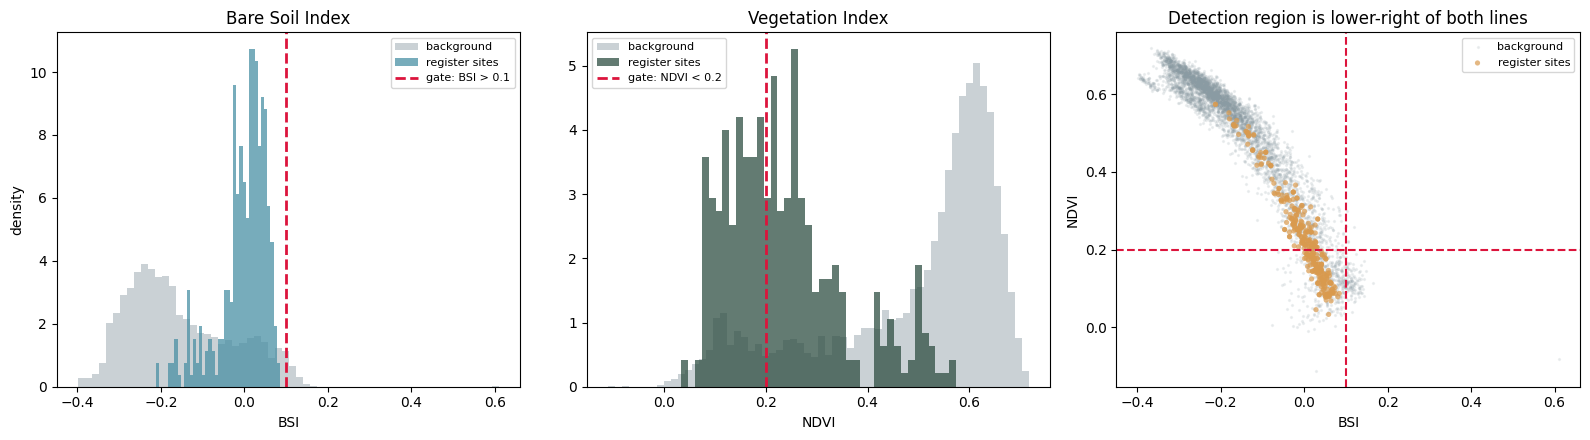

In [14]:
%matplotlib inline
# Register sites against a random background sample from the same scene.
rng = np.random.default_rng(42)
n_bg = 5000

# Sample background within the tile, excluding nodata (all-zero) pixels.
valid = band_array.sum(axis=2) > 0
vr, vc = np.where(valid)
pick = rng.choice(len(vr), size=min(n_bg, len(vr)), replace=False)
bg_bsi  = bsi[vr[pick], vc[pick]]
bg_ndvi = ndvi[vr[pick], vc[pick]]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(bg_bsi, bins=60, density=True, alpha=.45,
             color='#8a9ba3', label='background')
axes[0].hist(reg_samples.bsi, bins=40, density=True, alpha=.75,
             color='#4a90a4', label='register sites')
axes[0].axvline(BSI_T, color='crimson', ls='--', lw=2, label='gate: BSI > 0.1')
axes[0].set_xlabel('BSI'); axes[0].set_ylabel('density')
axes[0].set_title('Bare Soil Index'); axes[0].legend(fontsize=8)

axes[1].hist(bg_ndvi, bins=60, density=True, alpha=.45,
             color='#8a9ba3', label='background')
axes[1].hist(reg_samples.ndvi, bins=40, density=True, alpha=.75,
             color='#2f4f43', label='register sites')
axes[1].axvline(NDVI_T, color='crimson', ls='--', lw=2, label='gate: NDVI < 0.2')
axes[1].set_xlabel('NDVI'); axes[1].set_title('Vegetation Index'); axes[1].legend(fontsize=8)

axes[2].scatter(bg_bsi, bg_ndvi, s=2, alpha=.12, color='#8a9ba3', label='background')
axes[2].scatter(reg_samples.bsi, reg_samples.ndvi, s=14, alpha=.7,
                color='#d99a4e', edgecolor='none', label='register sites')
axes[2].axvline(BSI_T, color='crimson', ls='--', lw=1.5)
axes[2].axhline(NDVI_T, color='crimson', ls='--', lw=1.5)
axes[2].set_xlabel('BSI'); axes[2].set_ylabel('NDVI')
axes[2].set_title('Detection region is lower-right of both lines')
axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()
(ROOT / 'docs' / 'images').mkdir(parents=True, exist_ok=True)
fig.savefig(ROOT / 'docs' / 'images' / 'register_vs_gate.png', dpi=150, bbox_inches='tight')

The scatter panel renders the finding directly. The detection region lies to the lower right of both threshold lines, requiring BSI above 0.1 and NDVI below 0.2 simultaneously. Every register site falls outside it. The register cloud runs diagonally along the inverse relationship between the two indices and terminates before the BSI threshold, with the closest sites reaching approximately 0.084.

The background distribution is bimodal in both indices, which is expected of an urban area. One population sits at BSI around −0.23 with NDVI near 0.6, corresponding to vegetated surfaces, and a second sits near BSI 0 with lower NDVI, corresponding to built and impervious surfaces. Register sites overlap the second population almost entirely. They are neither fully vegetated nor bare, which is consistent with previously developed land that has been partially colonised since it ceased operating.

The more consequential observation concerns separability. In the BSI panel the register and background distributions occupy the same range and differ mainly in the height of their peaks, not in their location. There is no interval of BSI within which a location is more likely to be registered brownfield than to be something else. The same holds for NDVI, where the register overlaps the lower mode of the background. This bears directly on issue #105, which proposed testing whether a classifier could separate register sites from background. On these features it cannot, because the distributions are superimposed rather than merely overlapping. A viable classifier would require features not examined here: texture, parcel geometry, spatial context, multi-year change, or non-image data such as occupancy or planning records.

## 7. Conclusion

This notebook set out to establish what registered brownfield looks like in Sentinel-2 imagery, and whether it possesses a signature the detector could reach. Four results follow.

Registered brownfield in Stoke is vegetated, not bare. The mean NDVI across the 352 sites in the 2026 register is 0.234 and the mean BSI is −0.003. These are the values of grassed ground. The sites are former schools, hospitals, works and yards which ceased operating and have since been colonised. They satisfy the statutory definition of previously developed land whilst failing every spectral test for bare ground.

The detector cannot reach them. Its gate requires BSI above 0.1 and NDVI below 0.2. No register site satisfies both conditions, and none satisfies the BSI condition alone. The highest BSI value recorded anywhere in the register is 0.0843 against a threshold of 0.1. The recall of the current pipeline against registered brownfield is not low; it is zero, and every non-zero figure previously reported was an artefact of a hundred metre matching radius which credits a candidate with finding a site it does not occupy.

Register sites are not separable from background on these features. Their BSI and NDVI distributions are superimposed on the urban background rather than merely overlapping it. There is no threshold, and no combination of these two indices, which isolates them.

Site size is a real but secondary constraint. Thirty-eight and a half per cent of the register falls below the 0.2 hectare detection floor imposed by the minimum cluster size. That would be the binding limitation if the remainder were detectable. They are not, for reasons independent of scale.

Taken together these results identify the root cause of the failures documented throughout this project. The product was defined as persistently-bare, unregistered, developable land, and the detector was built to find bare ground. The target, as represented by the only ground truth available, is not bare. The two definitions were assumed to coincide and do not. Notebook 08 established that persistence selects for permanence of use rather than absence of it; this notebook establishes the prior fact that the candidate pool persistence operated on could never have contained the target in the first place.

### What this means for the architecture

Notebook 07 left open a choice between two designs. Fork A places a supervised classifier downstream of the threshold gate to re-rank the candidates it emits. Fork B replaces the gate with a model trained on register locations sampled independently of any threshold.

Fork A is now closed. A classifier cannot re-rank sites which never entered the candidate pool, and section 5 established that the stored features carry no signal distinguishing register-matched candidates from unmatched ones, with a maximum effect size of −0.372 and both gate indices near zero.

Fork B is not closed but the evidence against it has strengthened. Section 6 shows that the positive class is not separable from background on the spectral features available at this resolution. A model trained on BSI, NDVI and reflectance bands would have nothing to learn. Any viable replacement would require a different feature space: texture, parcel geometry, spatial context, multi-year phenological change, or non-image sources such as occupancy and planning records. That is a different system rather than a modification of this one.

### Limitations

The register stores point locations rather than polygons, and it is not established whether those points represent site centroids or another reference position. Sampling used a square window sized to the recorded area and centred on the stored point, so an offset reference would displace the window. The effect would be to introduce noise rather than bias in a particular direction, and it is unlikely to account for a result in which no site in the register approaches the threshold.

Sampling was performed on a single date, 25 May 2026. Spring is close to peak growth in this region and therefore represents the vegetated extreme of the annual cycle. A winter scene would show register sites at their barest and would raise the measured BSI. Notebook 08 established that winter produces the fewest candidates overall, so the direction of that change is unlikely to reverse the finding, but the margin would narrow and the sampling should be repeated across all four dates before the result is quoted externally.

The background comparison drew 5,000 random points from the full tile rather than from within the council boundary, so it includes rural land beyond Stoke. This makes the vegetation mode more prominent than a boundary-restricted sample would, though it does not affect the position of the register distribution or its relationship to the threshold.

### Next steps

The immediate consequence is documentary. Recall figures quoted in Notebooks 06, 07 and 08, and in the project README, derive from the hundred metre match and overstate detection. They should be corrected or marked void, and the matching test itself should be rewritten to use polygon containment now that candidate geometry is persisted following FND-3. This is recorded as a defect in the evaluation harness rather than in the detector.

Issue #105 should be reconsidered rather than run as specified. It proposed testing whether a classifier could separate register sites from background using the existing feature set. Section 6 answers that question negatively before any model is trained. If the ticket proceeds it should be rewritten to test a different feature space, and the case for doing so is weaker than it was when the ticket was raised.

Issues #96, #100 and #101 all concern the removal of false positives from the candidate pool. They remain valid as engineering work but their value has changed. Removing active industrial sites from a pool which contains no registered brownfield improves precision on a set that does not contain the target. They should be treated as deferred rather than closed, since they would become relevant again under a corrected detector.

The remaining open question is whether any sensor and method combination can detect this target. The literature reviewed alongside this work indicates that the discrimination between derelict and operational land has not been solved from optical imagery alone at any resolution, and that the approaches which make progress supplement imagery with non-image data such as land surface temperature, occupancy records or land use vectors. Establishing whether such an approach is viable for a UK council area is a separate investigation and is not a modification of the present pipeline.

In [15]:
conn.close()
print('Connection closed')

Connection closed
